Sample experiment to run different simulations for a data center, assuming different geographical locations, by providing different carbon trace files in order to map electricity usage to the respective areas carbon trace

In [18]:
import os
import subprocess

#for local debug
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@21"
os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:" + os.environ["PATH"]

#change experiment name based on json filename and name field inside json
experimentName = "sample_experiment"
pathToScenario = f"input/experiments/{experimentName}.json"

subprocess.run(["OpenDCExperimentRunner/bin/OpenDCExperimentRunner", "--experiment-path", pathToScenario])




 Running scenario: 0 
 Starting seed: 0 


Simulating...   0% [                                       ] 0/2 (0:00:00 / ?) 

19:24:25.813 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 24 hours:
						Tasks Total: 551
						Tasks Active: 124
						Tasks Pending: 0
						Tasks Completed: 427
						Tasks Terminated: 0

19:24:25.952 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 48 hours:
						Tasks Total: 1024
						Tasks Active: 78
						Tasks Pending: 0
						Tasks Completed: 946
						Tasks Terminated: 0

19:24:26.088 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 72 hours:
						Tasks Total: 1421
						Tasks Active: 81
						Tasks Pending: 0
						Tasks Completed: 1340
						Tasks Terminated: 0

19:24:26.437 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 96 hours:
						Tasks Total: 2037
						Tasks Active: 130
						Tasks Pending: 0
						Tasks Completed: 1907
						Tasks Terminated: 0

19:24:26.603 [WARN ] org.opendc.compute.simulator.tel

Simulating...  50% [================                 ] 1/2 (0:00:03 / 0:00:03) 

19:24:27.635 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 72 hours:
						Tasks Total: 1421
						Tasks Active: 81
						Tasks Pending: 0
						Tasks Completed: 1340
						Tasks Terminated: 0

19:24:27.765 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 96 hours:
						Tasks Total: 2037
						Tasks Active: 130
						Tasks Pending: 0
						Tasks Completed: 1907
						Tasks Terminated: 0

19:24:27.903 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 120 hours:
						Tasks Total: 2647
						Tasks Active: 66
						Tasks Pending: 0
						Tasks Completed: 2581
						Tasks Terminated: 0

19:24:28.022 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 144 hours:
						Tasks Total: 3918
						Tasks Active: 161
						Tasks Pending: 0
						Tasks Completed: 3757
						Tasks Terminated: 0

19:24:28.150 [WARN ] org.opendc.compute.simulato

Simulating... 100% [=================================] 2/2 (0:00:03 / 0:00:00) 


CompletedProcess(args=['OpenDCExperimentRunner/bin/OpenDCExperimentRunner', '--experiment-path', 'input/experiments/sample_experiment.json'], returncode=0)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_host_BE = pd.read_parquet(f"output/{experimentName}/raw-output/0/seed=0/host.parquet")
df_powerSource_BE = pd.read_parquet(f"output/{experimentName}/raw-output/0/seed=0/powerSource.parquet")
df_task_BE = pd.read_parquet(f"output/{experimentName}/raw-output/0/seed=0/task.parquet")
df_service_BE = pd.read_parquet(f"output/{experimentName}/raw-output/0/seed=0/service.parquet")

df_host_NL = pd.read_parquet(f"output/{experimentName}/raw-output/1/seed=0/host.parquet")
df_powerSource_NL = pd.read_parquet(f"output/{experimentName}/raw-output/1/seed=0/powerSource.parquet")
df_task_NL = pd.read_parquet(f"output/{experimentName}/raw-output/1/seed=0/task.parquet")
df_service_NL = pd.read_parquet(f"output/{experimentName}/raw-output/1/seed=0/service.parquet")

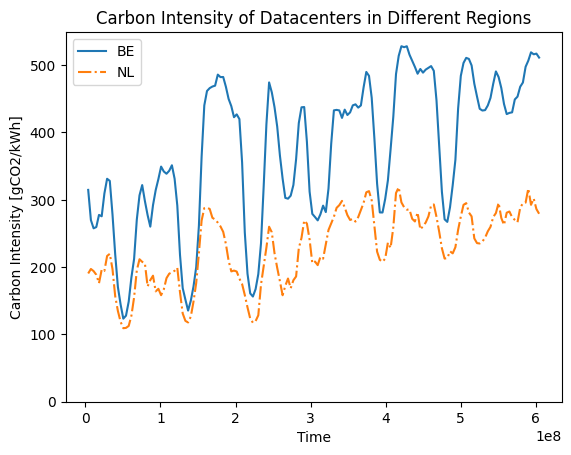

In [15]:
plt.plot(df_powerSource_BE["timestamp"], df_powerSource_BE["carbon_intensity"], label="BE")
plt.plot(df_powerSource_NL["timestamp"], df_powerSource_NL["carbon_intensity"], label="NL", linestyle='-.')

plt.legend()
plt.xlabel("Time")
plt.ylim([0, None])
plt.ylabel("Carbon Intensity [gCO2/kWh]")
plt.title("Carbon Intensity of Datacenters in Different Regions")

plt.show()

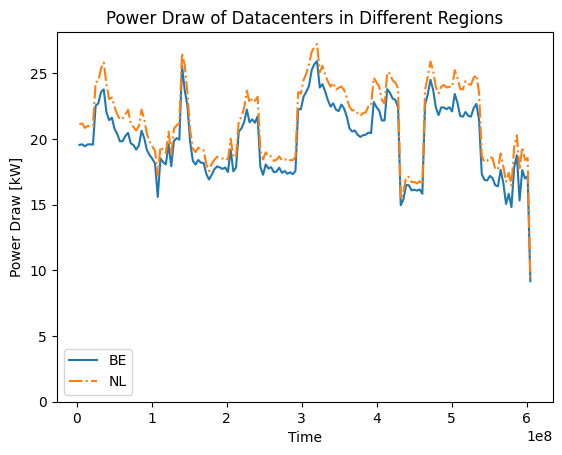

In [16]:
plt.plot(df_powerSource_BE["timestamp"], df_powerSource_BE["power_draw"] / 1000, label="BE")
plt.plot(df_powerSource_NL["timestamp"], df_powerSource_NL["power_draw"] / 1000, label="NL", linestyle='-.')

plt.legend()
plt.xlabel("Time")
plt.ylim([0, None])
plt.ylabel("Power Draw [kW]")
plt.title("Power Draw of Datacenters in Different Regions")

plt.show()

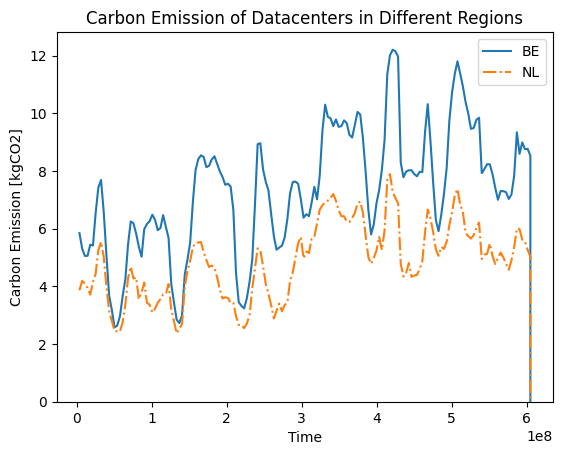

In [17]:
plt.plot(df_powerSource_BE["timestamp"], df_powerSource_BE["carbon_emission"] / 1000, label="BE")
plt.plot(df_powerSource_NL["timestamp"], df_powerSource_NL["carbon_emission"] / 1000, label="NL", linestyle='-.')

plt.legend()
plt.xlabel("Time")
plt.ylim([0, None])
plt.ylabel("Carbon Emission [kgCO2]")
plt.title("Carbon Emission of Datacenters in Different Regions")

plt.show()

In [10]:
carbon_BE = df_powerSource_BE["carbon_emission"].sum() / 1000
carbon_NL = df_powerSource_NL["carbon_emission"].sum() / 1000

print(f"Total Carbon Emission Belgium:     {carbon_BE:.2f} kgCO2")
print(f"Total Carbon Emission Netherlands: {carbon_NL:.2f} kgCO2\n")



Total Carbon Emission Belgium:     1233.28 kgCO2
Total Carbon Emission Netherlands: 816.30 kgCO2

